<a href="https://colab.research.google.com/github/varthanharsh35-ux/24ADI003_24BAD033/blob/main/EX08_SCENARIO%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
print("Harshavardhan J\n24BAD033")

Harshavardhan J
24BAD033


## Step 2: Load the Dataset

In [18]:
df = pd.read_csv('Groceries_dataset.csv')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (38765, 3)

First 5 rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [19]:
print('Dataset Info:')
print(f'  Total records     : {len(df)}')
print(f'  Unique members    : {df["Member_number"].nunique()}')
print(f'  Unique items      : {df["itemDescription"].nunique()}')
print(f'  Date range        : {df["Date"].min()} to {df["Date"].max()}')
print('\nTop 10 most purchased items:')
print(df['itemDescription'].value_counts().head(10))

Dataset Info:
  Total records     : 38765
  Unique members    : 3898
  Unique items      : 167
  Date range        : 01-01-2014 to 31-10-2015

Top 10 most purchased items:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


## Step 3: Data Preprocessing – One-Hot Encoding

In [20]:
# Group items by Member_number and Date to form transactions
basket = df.groupby(['Member_number', 'Date'])['itemDescription'] \
           .apply(list).reset_index()

print(f'Total transactions: {len(basket)}')
print('\nSample transactions:')
basket.head()

Total transactions: 14963

Sample transactions:


,Member_number,Date,itemDescription
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yog..."
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"


In [21]:
# Convert to one-hot encoded format using TransactionEncoder
transactions = basket['itemDescription'].tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded matrix shape: {df_encoded.shape}')
print('\nSample of encoded data (first 5 rows, first 8 columns):')
df_encoded.iloc[:5, :8]

Encoded matrix shape: (14963, 167)

Sample of encoded data (first 5 rows, first 8 columns):


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## Step 4 & 5: Generate Frequent Itemsets with Minimum Support

In [22]:
# Note: Grocery data has many items across 14963 transactions.
# We use min_support=0.005 (0.5%) to capture meaningful item pairs.
MIN_SUPPORT = 0.005

frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Minimum Support Threshold : {MIN_SUPPORT} ({MIN_SUPPORT*100}%)')
print(f'Total frequent itemsets   : {len(frequent_itemsets)}')
print(f'\nBreakdown by itemset size:')
print(frequent_itemsets['length'].value_counts().sort_index())
print('\nTop 10 frequent itemsets:')
frequent_itemsets.head(10)

Minimum Support Threshold : 0.005 (0.5%)
Total frequent itemsets   : 126

Breakdown by itemset size:
length
1    89
2    37
Name: count, dtype: int64

Top 10 frequent itemsets:


,support,itemsets,length
0,0.157923,(whole milk),1
1,0.122101,(other vegetables),1
2,0.110005,(rolls/buns),1
3,0.097106,(soda),1
4,0.085879,(yogurt),1
5,0.069572,(root vegetables),1
6,0.067767,(tropical fruit),1
7,0.060683,(bottled water),1
8,0.060349,(sausage),1
9,0.053131,(citrus fruit),1


### Observe Effect of Support Threshold on Itemset Count

In [23]:
thresholds = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
counts = []

for t in thresholds:
    fi = apriori(df_encoded, min_support=t, use_colnames=True)
    counts.append(len(fi))
    print(f'Support = {t:.3f}  ->  {len(fi):>4} frequent itemsets')

Support = 0.003  ->   216 frequent itemsets
Support = 0.005  ->   126 frequent itemsets
Support = 0.007  ->    90 frequent itemsets
Support = 0.010  ->    69 frequent itemsets
Support = 0.015  ->    50 frequent itemsets
Support = 0.020  ->    38 frequent itemsets


## Step 6 and 7: Generate and Filter Association Rules

In [24]:
# Generate association rules with confidence >= 5%
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.05,
    num_itemsets=len(frequent_itemsets)
)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total rules generated: {len(rules)}')
print('\nTop 10 rules by lift:')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total rules generated: 57

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
0,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
1,(yogurt),(sausage),0.005748,0.066926,1.108986
2,(sausage),(yogurt),0.005748,0.095238,1.108986
3,(sausage),(soda),0.005948,0.098560,1.014975
4,(soda),(sausage),0.005948,0.061253,1.014975
5,(bottled beer),(whole milk),0.007151,0.157817,0.999330
6,(sausage),(whole milk),0.008955,0.148394,0.939663
7,(whole milk),(sausage),0.008955,0.056708,0.939663
8,(newspapers),(whole milk),0.005614,0.144330,0.913926
9,(domestic eggs),(whole milk),0.005280,0.142342,0.901341


In [25]:
# Filter strong rules: lift > 1.0 and confidence >= 10%
strong_rules = rules[(rules['lift'] > 1.0) & (rules['confidence'] >= 0.10)]
strong_rules = strong_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Strong rules (lift > 1.0, confidence >= 10%): {len(strong_rules)}')
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Strong rules (lift > 1.0, confidence >= 10%): 1


,antecedents,consequents,support,confidence,lift
0,(frankfurter),(other vegetables),0.005146,0.136283,1.11615


## Step 8: Interpret Rules

In [26]:
print('=' * 60)
print('TOP 5 ASSOCIATION RULES - INTERPRETATION')
print('=' * 60)

for i, row in rules.head(5).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f'\nRule {i+1}: [{ant}] -> [{con}]')
    print(f'  Support    = {row["support"]:.4f}  -> occurs in {row["support"]*100:.2f}% of transactions')
    print(f'  Confidence = {row["confidence"]:.4f}  -> {row["confidence"]*100:.1f}% of buyers of "{ant}" also buy "{con}"')
    print(f'  Lift       = {row["lift"]:.4f}  -> {row["lift"]:.2f}x more likely than random chance')
    if row['lift'] > 1:
        print(f'  => Positive association: buying "{ant}" increases likelihood of "{con}"')
    else:
        print(f'  => Lift < 1: items co-occur less than expected')

TOP 5 ASSOCIATION RULES - INTERPRETATION

Rule 1: [frankfurter] -> [other vegetables]
  Support    = 0.0051  -> occurs in 0.51% of transactions
  Confidence = 0.1363  -> 13.6% of buyers of "frankfurter" also buy "other vegetables"
  Lift       = 1.1161  -> 1.12x more likely than random chance
  => Positive association: buying "frankfurter" increases likelihood of "other vegetables"

Rule 2: [yogurt] -> [sausage]
  Support    = 0.0057  -> occurs in 0.57% of transactions
  Confidence = 0.0669  -> 6.7% of buyers of "yogurt" also buy "sausage"
  Lift       = 1.1090  -> 1.11x more likely than random chance
  => Positive association: buying "yogurt" increases likelihood of "sausage"

Rule 3: [sausage] -> [yogurt]
  Support    = 0.0057  -> occurs in 0.57% of transactions
  Confidence = 0.0952  -> 9.5% of buyers of "sausage" also buy "yogurt"
  Lift       = 1.1090  -> 1.11x more likely than random chance
  => Positive association: buying "sausage" increases likelihood of "yogurt"

Rule 4: [sau

## Visualizations
### Plot 1: Bar Chart of Top Frequent Items

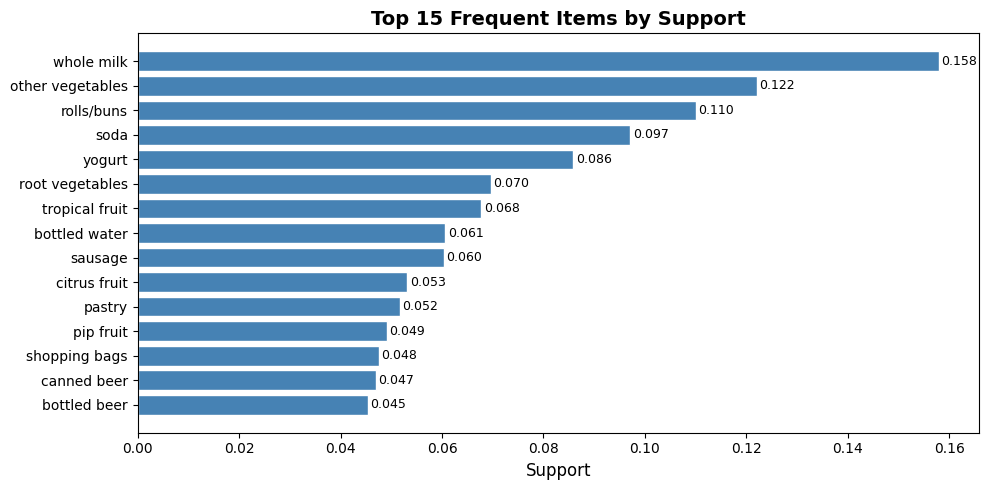

In [27]:
top_items = frequent_itemsets[frequent_itemsets['length'] == 1].nlargest(15, 'support').copy()
top_items['item'] = top_items['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 5))
bars = plt.barh(top_items['item'][::-1], top_items['support'][::-1],
                color='steelblue', edgecolor='white')
plt.xlabel('Support', fontsize=12)
plt.title('Top 15 Frequent Items by Support', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_items['support'][::-1]):
    plt.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 2: Effect of Support Threshold on Itemset Count

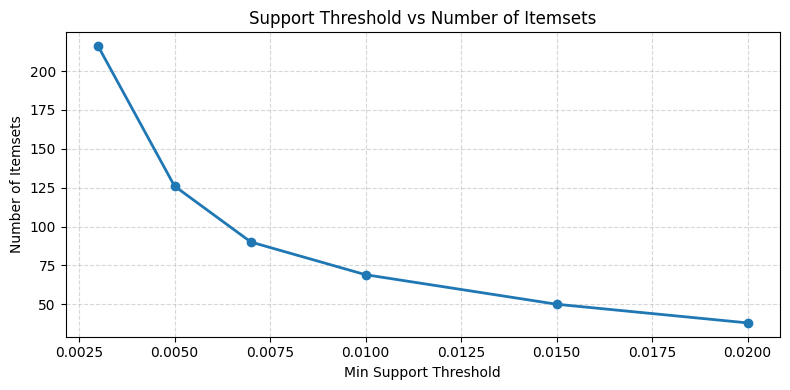

In [28]:
plt.figure(figsize=(8, 4))

plt.plot(thresholds, counts, marker='o', linewidth=2)

plt.xlabel('Min Support Threshold')
plt.ylabel('Number of Itemsets')
plt.title('Support Threshold vs Number of Itemsets')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Plot 3: Support vs Confidence Scatter Plot (colored by Lift)

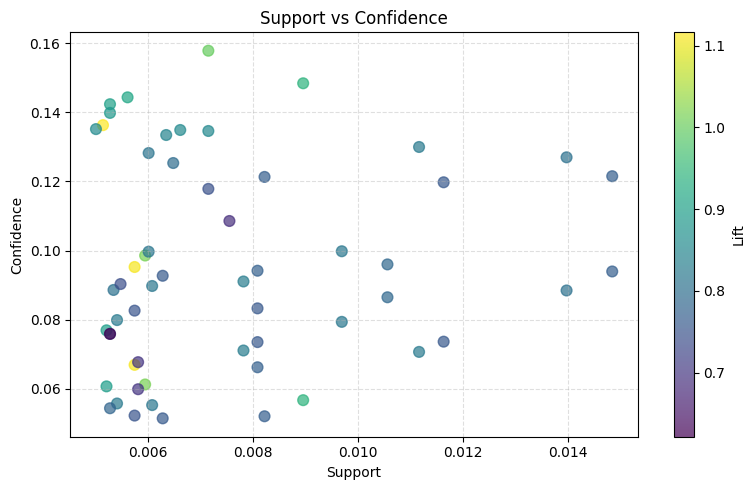

In [29]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='viridis',
    s=60,
    alpha=0.7
)

plt.colorbar(sc, label='Lift')

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Plot 4: Network Graph of Association Rules

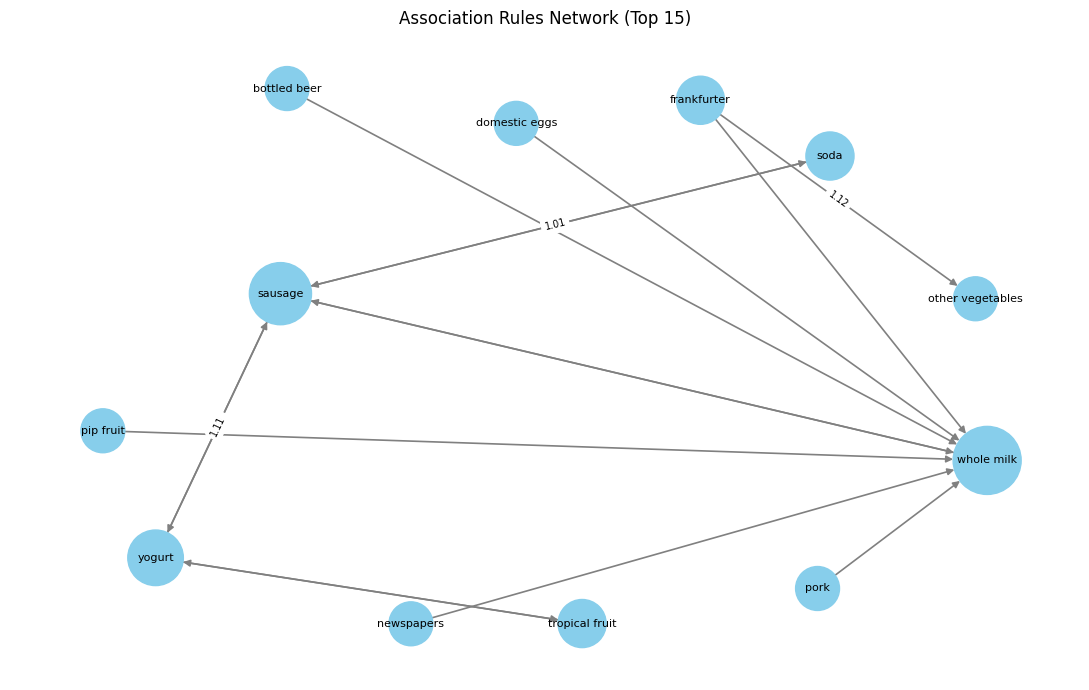

In [30]:
# Use top 15 rules (reduce clutter)
top_rules = rules.head(15)

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=round(row['lift'], 2))

plt.figure(figsize=(11, 7))

pos = nx.spring_layout(G, seed=42, k=2)

# Node size based on degree
degrees = dict(G.degree())
node_sizes = [800 + 200 * degrees[n] for n in G.nodes()]

nx.draw_networkx(
    G, pos,
    node_size=node_sizes,
    node_color='skyblue',
    font_size=8,
    edge_color='gray',
    width=1.2,
    arrows=True
)

# Optional: show only few edge labels (top 5 by lift)
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
edge_labels = {(u, v): d['weight'] for u, v, d in edges_sorted}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title('Association Rules Network (Top 15)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Comparing Rules at Different Confidence Levels

In [31]:
conf_levels = [0.05, 0.08, 0.10, 0.12, 0.15]
print(f'{"Min Confidence":>16} | {"Rule Count":>11} | {"Avg Lift":>10} | {"Max Lift":>10}')
print('-' * 56)
for c in conf_levels:
    filtered = rules[rules['confidence'] >= c]
    if len(filtered) > 0:
        print(f'     >= {c:.2f}      |     {len(filtered):>5}     |  {filtered["lift"].mean():.4f}   |  {filtered["lift"].max():.4f}')
    else:
        print(f'     >= {c:.2f}      |         0     |      -        |      -')

  Min Confidence |  Rule Count |   Avg Lift |   Max Lift
--------------------------------------------------------
     >= 0.05      |        57     |  0.8278   |  1.1161
     >= 0.08      |        35     |  0.8358   |  1.1161
     >= 0.10      |        19     |  0.8487   |  1.1161
     >= 0.12      |        16     |  0.8708   |  1.1161
     >= 0.15      |         1     |  0.9993   |  0.9993


In [32]:
print('  APRIORI ASSOCIATION RULE MINING - FINAL SUMMARY')
print(f'  Dataset rows           : {len(df):>8}')
print(f'  Total transactions     : {len(basket):>8}')
print(f'  Unique items           : {df["itemDescription"].nunique():>8}')
print(f'  Min support used       :    0.005 (0.5%)')
print(f'  Frequent itemsets      : {len(frequent_itemsets):>8}')
print(f'  Association rules      : {len(rules):>8}')
print(f'  Strong rules (lift>1)  : {len(rules[rules["lift"]>1.0]):>8}')
print()
print('  Rules Statistics:')
print(rules[['support', 'confidence', 'lift']].describe().round(4).to_string())
print()
print('  Evaluation Metrics:')
print('  - Support    : Proportion of transactions containing the itemset')
print('  - Confidence : Probability of buying Y given X was bought')
print('  - Lift       : How much more likely X->Y vs random (>1 = positive)')

  APRIORI ASSOCIATION RULE MINING - FINAL SUMMARY
  Dataset rows           :    38765
  Total transactions     :    14963
  Unique items           :      167
  Min support used       :    0.005 (0.5%)
  Frequent itemsets      :      126
  Association rules      :       57
  Strong rules (lift>1)  :        5

  Rules Statistics:
       support  confidence     lift
count  57.0000     57.0000  57.0000
mean    0.0076      0.0950   0.8278
std     0.0026      0.0300   0.1015
min     0.0050      0.0515   0.6215
25%     0.0057      0.0711   0.7681
50%     0.0063      0.0903   0.8118
75%     0.0082      0.1215   0.8541
max     0.0148      0.1578   1.1161

  Evaluation Metrics:
  - Support    : Proportion of transactions containing the itemset
  - Confidence : Probability of buying Y given X was bought
  - Lift       : How much more likely X->Y vs random (>1 = positive)
